In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import scipy
import seaborn as sns
import sklearn
import pysindy as ps 
from sklearn.linear_model import Lasso,Ridge,ElasticNet
from tools import get_positive_contributions, compute_entropy, print_equations
from data_func import plot_clustered_kuramoto, generate_kuramoto_cluster_data_sin_cos
from matplotlib.gridspec import GridSpec
from scipy import signal
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from collections import Counter
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# 设置美观的图形样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体（支持中文）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题
warnings.filterwarnings('ignore', message='.*U\\+2212.*')

# 数据生成

In [2]:
def generate_two_population_neuron_data(
    n_a=400, n_b=400,              # 两个群体的神经元数量
    alpha_a=4.6,                 # α群体的α参数（可激发性）
    alpha_b=4.6,                 # β群体的α参数
    sigma_a=0.225,                 # α群体的σ参数（异质性）
    sigma_b=0.225,                 # β群体的σ参数
    mu=0.001,                    # 慢变参数（局部动力学）
    gamma=0.08,                   # 群体内耦合强度（μ）
    epsilon=0.04,                # 群体间耦合强度（ε）
    T=10000,                     # 总模拟步数
    transients=1000,             # 舍弃的暂态步数
    x0_a=-1, x0_b=-0.5,          # a/b群体x初始值（None则该群体独立随机）
    y0_a=-3.5, y0_b=-3, 
    seed=42                      # 随机种子
):
    """
    生成两个群体神经元数据，基于平均场耦合动力学。
    
    参数:
        n_a, n_b: 两个群体的神经元数量
        alpha_a, alpha_b: 两个群体的可激发性参数
        sigma_a, sigma_b: 两个群体的异质性参数
        mu: 慢变参数（局部动力学）
        gamma: 群体内耦合强度（对应图中的μ）
        epsilon: 群体间耦合强度（对应图中的ε）
        T: 总模拟步数
        transients: 舍弃的暂态步数
        seed: 随机种子
        
    返回:
        dict: 包含所有数据的字典
    """
    # 设置随机种子
    np.random.seed(seed)
    
    # 总神经元数
    N = n_a + n_b
    
    # 处理参数：如果是标量，扩展为列表
    if isinstance(alpha_a, (int, float)):
        alpha_a = np.full(n_a, alpha_a)
    else:
        alpha_a = np.array(alpha_a)
        
    if isinstance(alpha_b, (int, float)):
        alpha_b = np.full(n_b, alpha_b)
    else:
        alpha_b = np.array(alpha_b)
    
    if isinstance(sigma_a, (int, float)):
        sigma_a = np.full(n_a, sigma_a)
    else:
        sigma_a = np.array(sigma_a)
        
    if isinstance(sigma_b, (int, float)):
        sigma_b = np.full(n_b, sigma_b)
    else:
        sigma_b = np.array(sigma_b)
    # 合并所有参数
    alpha_all = np.concatenate([alpha_a, alpha_b])
    sigma_all = np.concatenate([sigma_a, sigma_b])
            
    # 初始化数组
    x_series = np.zeros((N, T))
    y_series = np.zeros((N, T))
     
    if x0_a is None:
        # None → a群体每个神经元独立随机
        x_series[:n_a, 0] = np.random.uniform(-1.5, -0.5, n_a)
        x0_a_record = "随机值（每个神经元独立）"
    else:
        # 传值 → a群体所有神经元共用该值
        x_series[:n_a, 0] = x0_a
        x0_a_record = x0_a
    
    if x0_b is None:
        # None → b群体每个神经元独立随机
        x_series[n_a:, 0] = np.random.uniform(-1.5, -0.5, n_b)
        x0_b_record = "随机值（每个神经元独立）"
    else:
        # 传值 → b群体所有神经元共用该值
        x_series[n_a:, 0] = x0_b
        x0_b_record = x0_b
    
    # 处理a群体y初始值
    if y0_a is None:
        y_series[:n_a, 0] = np.random.uniform(-4, -3, n_a)
        y0_a_record = "随机值（每个神经元独立）"
    else:
        y_series[:n_a, 0] = y0_a
        y0_a_record = y0_a
    
    # 处理b群体y初始值
    if y0_b is None:
        y_series[n_a:, 0] = np.random.uniform(-4, -3, n_b)
        y0_b_record = "随机值（每个神经元独立）"
    else:
        y_series[n_a:, 0] = y0_b
        y0_b_record = y0_b
    
    # 定义分段函数 f (局部动力学)
    def f(x_val, y_val, alpha):
        """Chialvo神经元模型的非线性函数"""
        if x_val <= 0:
            return alpha / (1 - x_val) + y_val
        elif 0 < x_val < alpha + y_val:
            return alpha + y_val
        else:
            return -1
    
    # 定义函数 g (慢变量动力学)
    def g(x_val, y_val, mu, sigma):
        """慢变量的更新函数"""
        return y_val - mu * (x_val + 1) + mu * sigma
    
    # 模拟迭代
    for t in range(T-1):
        # 计算两个群体的平均场
        # a群体的平均场
        Xbar_a = np.mean(x_series[:n_a, t])
        # b群体的平均场
        Xbar_b = np.mean(x_series[n_a:, t])
        
        # 更新a群体的神经元
        for i in range(n_a):
            # 局部动力学部分
            local_part = f(x_series[i, t], y_series[i, t], alpha_all[i])
            
            # 根据公式: x_{t+1} = (1-γ)f(...) + γXbar_a + εXbar_b
            x_series[i, t+1] = (1 - gamma) * local_part + gamma * Xbar_a + epsilon * Xbar_b
            
            # 根据公式: y_{t+1} = g(x_t, y_t)
            y_series[i, t+1] = g(x_series[i, t], y_series[i, t], mu, sigma_all[i])
        
        # 更新b群体的神经元
        for j in range(n_b):
            idx = n_a + j  # 在总数组中的索引
            
            # 局部动力学部分
            local_part = f(x_series[idx, t], y_series[idx, t], alpha_all[idx])
            
            # 根据公式: x_{t+1} = (1-γ)f(...) + γXbar_b + εXbar_a
            x_series[idx, t+1] = (1 - gamma) * local_part + gamma * Xbar_b + epsilon * Xbar_a
            
            # 根据公式: y_{t+1} = g(x_t, y_t)
            y_series[idx, t+1] = g(x_series[idx, t], y_series[idx, t], mu, sigma_all[idx])
        
    # 计算同步指标
    def compute_instantaneous_std(x_data, mean_field):
        N_neurons = x_data.shape[0]
        T_steps = x_data.shape[1]
        r_t = np.zeros(T_steps)
        
        for t in range(T_steps):
            # 计算每个时刻的标准差
            r_t[t] = np.sqrt(np.mean((x_data[:, t] - mean_field[t])**2))
        
        return r_t
    
    # 计算平均场时间序列
    Xbar_a = np.zeros(T)
    Xbar_b = np.zeros(T)
    
    for t in range(T):
        Xbar_a[t] = np.mean(x_series[:n_a, t])
        Xbar_b[t] = np.mean(x_series[n_a:, t])
    Xbar_a_transient = Xbar_a[transients:]
    Xbar_b_transient = Xbar_b[transients:]
    # 计算瞬时标准差
    r_a_t = compute_instantaneous_std(x_series[:n_a, :], Xbar_a)
    r_b_t = compute_instantaneous_std(x_series[n_a:, :], Xbar_b)
    r_a_t_transient = r_a_t[transients:]
    r_b_t_transient = r_b_t[transients:]
    
    Xbar_all = np.zeros(T)
    for t in range(T):
        Xbar_all[t] = np.mean(x_series[:, t])
        
    r_t = compute_instantaneous_std(x_series, Xbar_all)
    r_t_transient = r_t[transients:]
    
    # 计算时间平均
    T_effective = T - transients
    R_a = np.mean(r_a_t_transient) 
    R_b = np.mean(r_b_t_transient) 
    R_t = np.mean(r_t_transient) 
    R_delta = np.mean(np.abs(Xbar_a[transients:] - Xbar_b[transients:]))  
    
    # 判断同步状态 (基于图片中的定义)
    def determine_sync_state(R_a, R_b, R_delta, threshold=1e-7):
        sync_a = R_a < threshold
        sync_b = R_b < threshold
        sync_ab = R_delta < threshold
        
        if sync_a and sync_b and sync_ab:
            return "Complete Synchronization 完全同步(CS)"
        elif sync_a and sync_b and not sync_ab:
            return "Generalized Synchronization 广义同步 (GS)"
        elif (sync_a and not sync_b) or (not sync_a and sync_b):
            return "Chimera State 奇美拉态(Q)"
        elif not sync_a and not sync_b:
            return "Desynchronization 去同步化(D)"
        else:
            return "Unknown State 未知"
    
    sync_state = determine_sync_state(R_a, R_b, R_delta)
    
    # 准备参数信息
    params = {
        '神经元总数': N,
        'a群体神经元数': n_a,
        'b群体神经元数': n_b,
        'a群体α参数': alpha_a[0] if isinstance(alpha_a, np.ndarray) and len(np.unique(alpha_a)) == 1 else f"列表({len(alpha_a)}个)",
        'b群体α参数': alpha_b[0] if isinstance(alpha_b, np.ndarray) and len(np.unique(alpha_b)) == 1 else f"列表({len(alpha_b)}个)",
        'a群体σ参数': sigma_a[0] if isinstance(sigma_a, np.ndarray) and len(np.unique(sigma_a)) == 1 else f"列表({len(sigma_a)}个)",
        'b群体σ参数': sigma_b[0] if isinstance(sigma_b, np.ndarray) and len(np.unique(sigma_b)) == 1 else f"列表({len(sigma_b)}个)",
        '慢变参数μ': mu,
        '群体内耦合强度γ': gamma,
        '群体间耦合强度ε': epsilon,
        '总步数': T,
        '舍弃暂态': transients,
        '有效数据长度': T_effective,
        '随机种子': seed
    }
    
    # 动力学特征
    dynamics_stats = {
        '⟨σa⟩ (R_a)': R_a,
        '⟨σb⟩ (R_b)': R_b,
        '⟨σt⟩ (R_t)': R_t,
        '⟨δ⟩ (R_delta)': R_delta,
        '同步状态': sync_state,
        'a群体同步': R_a < 1e-7,
        'b群体同步': R_b < 1e-7,
        'Rt群体同步': R_t < 1e-7,
        '群体间同步': R_delta < 1e-7,
        'r_a_t': r_a_t,
        'r_b_t': r_b_t,
        'r_t': r_t
    }
    # 准备返回数据
    data = {
        'params': {**params, **dynamics_stats},
        '群体信息': {
            'a群体神经元数': n_a,
            'b群体神经元数': n_b,
            'a群体索引': list(range(n_a)),
            'b群体索引': list(range(n_a, n_a + n_b)),
            'a群体α参数': alpha_a,
            'b群体α参数': alpha_b,
            'a群体σ参数': sigma_a,
            'b群体σ参数': sigma_b
        },
        '时间序列': {
            't': np.arange(T_effective),
            'Xbar_a': Xbar_a,  # a群体平均场
            'Xbar_b': Xbar_b,  # b群体平均场
            'Xbar_a_transient': Xbar_a_transient,  # a群体平均场
            'Xbar_b_transient': Xbar_b_transient,  # b群体平均场
            'r_a_t': r_a_t,   # a群体瞬时标准差
            'r_b_t': r_b_t,   # b群体瞬时标准差
            'r_t': r_t,   # 全部瞬时标准差
            'r_a_t_transient': r_a_t_transient,   # a群体瞬时标准差
            'r_b_t_transient': r_b_t_transient,   # b群体瞬时标准差
            'r_t_transient': r_t_transient   # 全部瞬时标准差
        },
        '同步指标': {
            'R_a': R_a,      # ⟨σα⟩的时间平均
            'R_b': R_b,      # ⟨σβ⟩的时间平均
            'R_t': R_t,      
            'R_delta': R_delta,  # ⟨δ⟩的时间平均
            'sync_state': sync_state
        }
    }
    
    # 添加每个神经元的完整时间序列
    for i in range(n_a):
        data[f'神经元_a_{i+1:03d}'] = {
            'x_transient': x_series[i, transients:],
            'y_transient': y_series[i, transients:],
            'x': x_series[i],
            'y': y_series[i],
            '群体': 'a',
            'α参数': alpha_a[i] if isinstance(alpha_a, np.ndarray) else alpha_a,
            'σ参数': sigma_a[i] if isinstance(sigma_a, np.ndarray) else sigma_a
        }
    
    for j in range(n_b):
        idx = n_a + j
        data[f'神经元_b_{j+1:03d}'] = {
            'x_transient': x_series[idx, transients:],
            'y_transient': y_series[idx, transients:],
            'x': x_series[idx],
            'y': y_series[idx],
            '群体': 'b',
            'α参数': alpha_b[j] if isinstance(alpha_b, np.ndarray) else alpha_b,
            'σ参数': sigma_b[j] if isinstance(sigma_b, np.ndarray) else sigma_b
        }
    
    return data

In [3]:
def plot_neuron_data(data, title="两群体神经元动态行为", figsize=(18, 10), 
                    show_last_n=None, neuron_sample=None):
    """
    绘制两群体神经元数据。
    
    参数:
        data: 生成的数据字典
        title: 图标题
        figsize: 图形大小
        show_last_n: 只显示最后n个时间点（避免过于拥挤），如果为None则显示全部
        neuron_sample: 每个群体显示的神经元数量，如果为None则显示全部
    """
    # 从数据中提取参数
    params = data['params']
    group_info = data['群体信息']
    time_series = data['时间序列']
    sync_info = data['同步指标']
    
    n_a = group_info['a群体神经元数']
    n_b = group_info['b群体神经元数']
    n_neurons = n_a + n_b
    
    # 时间点
    t = time_series['t']
    
    # 如果指定了show_last_n，只显示最后的部分
    if show_last_n is not None and show_last_n < len(t):
        start_idx = len(t) - show_last_n
        t_display = t[start_idx:]
    else:
        start_idx = 0
        t_display = t
    
    # 确定要绘制的神经元
    if neuron_sample is not None:
        # 从每个群体中随机选择指定数量的神经元
        np.random.seed(42)  # 固定随机种子以保证可重复性
        a_indices = np.random.choice(n_a, min(neuron_sample, n_a), replace=False)
        b_indices = np.random.choice(n_b, min(neuron_sample, n_b), replace=False)
    else:
        a_indices = list(range(n_a))
        b_indices = list(range(n_b))
    
    # 定义颜色列表 - 使用美观的调色板
    a_colors = ['#FF6B6B', '#FF8E8E', '#FFB2B2', '#FFD6D6']  # 暖色调
    b_colors = ['#4C72B0', '#6A8CC7', '#8CA6DE', '#AEC0F5']  # 冷色调
    avg_colors = ['#C44E52', '#2E5A8C']  # 平均场颜色
    
    # 创建图形
    fig = plt.figure(figsize=figsize, facecolor='white')
    gs = GridSpec(2, 3, figure=fig, height_ratios=[1, 1.2], hspace=0.25, wspace=0.3)
    
    # 第一行：所有神经元的x随时间变化（长子图，跨3列）
    ax1 = fig.add_subplot(gs[0, :])
    
    # 绘制a群体神经元的x-t曲线
    for idx, i in enumerate(a_indices):
        neuron_key = f'神经元_a_{i+1:03d}'
        x = data[neuron_key]['x_transient']
        if start_idx > 0:
            x = x[start_idx:]
        color_idx = idx % len(a_colors)
        ax1.plot(t_display, x, color=a_colors[color_idx], linewidth=0.8, 
                alpha=0.9, label=f'神经元_a_{i+1}' if idx < 5 else None)
    
    # 绘制b群体神经元的x-t曲线
    for idx, j in enumerate(b_indices):
        neuron_key = f'神经元_b_{j+1:03d}'
        x = data[neuron_key]['x_transient']
        if start_idx > 0:
            x = x[start_idx:]
        color_idx = idx % len(b_colors)
        ax1.plot(t_display, x, color=b_colors[color_idx], linewidth=0.8, 
                alpha=0.9, label=f'神经元_b_{j+1}' if idx < 5 else None)
    
    # 绘制平均场
    Xbar_a = time_series['Xbar_a_transient']
    Xbar_b = time_series['Xbar_b_transient']
    if start_idx > 0:
        Xbar_a = Xbar_a[start_idx:]
        Xbar_b = Xbar_b[start_idx:]
    
    ax1.plot(t_display, Xbar_a, color=avg_colors[0], linewidth=2.5, alpha=0.9, label='Xbar_a (α群体平均场)')
    ax1.plot(t_display, Xbar_b, color=avg_colors[1], linewidth=2.5, alpha=0.9, label='Xbar_b (β群体平均场)')
    
    ax1.set_xlabel('时间（迭代步）', fontsize=12)
    ax1.set_ylabel('快变量 x', fontsize=12)
    ax1.set_title('快变量x随时间变化', fontsize=14, fontweight='bold')
    
    # 智能图例：显示有限数量的神经元标签
    handles, labels = ax1.get_legend_handles_labels()
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)
    
    # 只显示前6个神经元标签和平均场标签
    legend_items = []
    legend_labels = []
    
    # 添加前几个神经元标签
    for i, label in enumerate(unique_labels):
        if '神经元_a' in label and len([l for l in legend_labels if '神经元_a' in l]) < 2:
            legend_items.append(unique_handles[i])
            legend_labels.append(label)
        elif '神经元_b' in label and len([l for l in legend_labels if '神经元_b' in l]) < 2:
            legend_items.append(unique_handles[i])
            legend_labels.append(label)
        elif '平均场' in label:
            legend_items.append(unique_handles[i])
            legend_labels.append(label)
    
    ax1.legend(legend_items, legend_labels, loc='upper right', fontsize=10, ncol=2)
    ax1.set_facecolor('white')  
    ax1.grid(False) 
    
    # 添加同步状态信息
    sync_state = sync_info.get('sync_state', 'Unknown')
    ax1.text(0.02, 0.98, f'同步状态: {sync_state}', transform=ax1.transAxes, 
            fontsize=11, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='gray'))
    
    # 第二行第一列：所有神经元的y随时间变化
    ax2 = fig.add_subplot(gs[1, 0])
    
    # 绘制a群体神经元的y-t曲线
    for idx, i in enumerate(a_indices):
        neuron_key = f'神经元_a_{i+1:03d}'
        y = data[neuron_key]['y_transient']
        if start_idx > 0:
            y = y[start_idx:]
        color_idx = idx % len(a_colors)
        ax2.plot(t_display, y, color=a_colors[color_idx], linewidth=0.8, 
                alpha=0.7, label=f'神经元_a_{i+1}' if idx < 3 else None)
    
    # 绘制b群体神经元的y-t曲线
    for idx, j in enumerate(b_indices):
        neuron_key = f'神经元_b_{j+1:03d}'
        y = data[neuron_key]['y_transient']
        if start_idx > 0:
            y = y[start_idx:]
        color_idx = idx % len(b_colors)
        ax2.plot(t_display, y, color=b_colors[color_idx], linewidth=0.8, 
                alpha=0.7, label=f'神经元_b_{j+1}' if idx < 3 else None)
    
    ax2.set_xlabel('时间（迭代步）', fontsize=12)
    ax2.set_ylabel('慢变量 y', fontsize=12)
    ax2.set_title('慢变量y随时间变化', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=9, ncol=2)
    ax2.set_facecolor('white')  
    ax2.grid(False) 
    
    # 第二行第二列：所有神经元的相平面图
    ax3 = fig.add_subplot(gs[1, 1])
    
    # 绘制a群体神经元的相平面图
    for idx, i in enumerate(a_indices):
        neuron_key = f'神经元_a_{i+1:03d}'
        x = data[neuron_key]['x_transient']
        y = data[neuron_key]['y_transient']
        if start_idx > 0:
            x = x[start_idx:]
            y = y[start_idx:]
        color_idx = idx % len(a_colors)
        ax3.plot(x, y, color=a_colors[color_idx], linewidth=0.8, alpha=0.7, 
                label=f'神经元_a_{i+1}' if idx < 3 else None)
        # 标记起点和终点
        ax3.scatter(x[0], y[0], color=a_colors[color_idx], s=20, zorder=5, 
                   marker='o', alpha=0.8)
        ax3.scatter(x[-1], y[-1], color=a_colors[color_idx], s=20, zorder=5, 
                   marker='s', alpha=0.8)
    
    # 绘制b群体神经元的相平面图
    for idx, j in enumerate(b_indices):
        neuron_key = f'神经元_b_{j+1:03d}'
        x = data[neuron_key]['x_transient']
        y = data[neuron_key]['y_transient']
        if start_idx > 0:
            x = x[start_idx:]
            y = y[start_idx:]
        color_idx = idx % len(b_colors)
        ax3.plot(x, y, color=b_colors[color_idx], linewidth=0.8, alpha=0.7, 
                label=f'神经元_b_{j+1}' if idx < 3 else None)
        # 标记起点和终点
        ax3.scatter(x[0], y[0], color=b_colors[color_idx], s=20, zorder=5, 
                   marker='o', alpha=0.8)
        ax3.scatter(x[-1], y[-1], color=b_colors[color_idx], s=20, zorder=5, 
                   marker='s', alpha=0.8)
    
    ax3.set_xlabel('快变量 x', fontsize=12)
    ax3.set_ylabel('慢变量 y', fontsize=12)
    ax3.set_title('相平面图 (x-y)', fontsize=14, fontweight='bold')
    ax3.legend(loc='best', fontsize=9, ncol=2)
    ax3.set_facecolor('white')  
    ax3.grid(False) 
    
    # 第二行第三列：参数信息
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.axis('off')
    
    # 构建参数文本
    param_text = "系统参数\n"
    param_text += "="*30 + "\n"
    
    # 同步状态信息
    param_text += f"同步状态: {sync_state}\n"
    param_text += f"σa (R_a) = {sync_info.get('R_a', 0):.4e}\n"
    param_text += f"σb (R_b) = {sync_info.get('R_b', 0):.4e}\n"
    param_text += f"δ (R_delta) = {sync_info.get('R_delta', 0):.4e}\n"
    param_text += "="*30 + "\n"
    
    # 神经元数量
    param_text += f"神经元总数: {params.get('神经元总数', 'N/A')}\n"
    param_text += f"α群体神经元数: {n_a}\n"
    param_text += f"β群体神经元数: {n_b}\n"
    param_text += "-"*30 + "\n"
    
    # 可激发性参数
    param_text += "可激发性参数:\n"
    if isinstance(group_info['a群体α参数'], (int, float, np.number)):
        param_text += f"  α_a = {group_info['a群体α参数']}\n"
    else:
        param_text += f"  α_a = 列表({len(group_info['a群体α参数'])}个)\n"
    
    if isinstance(group_info['b群体α参数'], (int, float, np.number)):
        param_text += f"  α_b = {group_info['b群体α参数']}\n"
    else:
        param_text += f"  α_b = 列表({len(group_info['b群体α参数'])}个)\n"
    
    # 异质性参数
    param_text += "异质性参数:\n"
    if isinstance(group_info['a群体σ参数'], (int, float, np.number)):
        param_text += f"  σ_a = {group_info['a群体σ参数']}\n"
    else:
        param_text += f"  σ_a = 列表({len(group_info['a群体σ参数'])}个)\n"
    
    if isinstance(group_info['b群体σ参数'], (int, float, np.number)):
        param_text += f"  σ_b = {group_info['b群体σ参数']}\n"
    else:
        param_text += f"  σ_b = 列表({len(group_info['b群体σ参数'])}个)\n"
    
    param_text += "-"*30 + "\n"
    
    # 动力学参数
    param_text += "动力学参数:\n"
    param_text += f"  慢变参数 μ = {params.get('慢变参数μ', 'N/A')}\n"
    param_text += f"  群体内耦合 γ = {params.get('群体内耦合强度γ', 'N/A')}\n"
    param_text += f"  群体间耦合 ε = {params.get('群体间耦合强度ε', 'N/A')}\n"
    
    param_text += "-"*30 + "\n"
    
    # 模拟参数
    param_text += "模拟参数:\n"
    param_text += f"  总步数: {params.get('总步数', 'N/A')}\n"
    param_text += f"  舍弃暂态: {params.get('舍弃暂态', 'N/A')}步\n"
    param_text += f"  有效数据: {params.get('有效数据长度', 'N/A')}步\n"
    param_text += f"  随机种子: {params.get('随机种子', 'N/A')}\n"
    
    # 计算合适的字体大小
    font_size = 9 if n_neurons > 20 else 10
    
    # 添加文本背景
    ax4.text(0.05, 0.98, param_text, fontsize=font_size, 
            verticalalignment='top', linespacing=1.5,
            bbox=dict(boxstyle='round', facecolor='#F0F0F0', 
                     alpha=0.9, edgecolor='#D3D3D3'))
    
    plt.suptitle(f'{title}', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    
    return fig

In [4]:
def plot_neuron_state_heatmap(data, figsize=(15, 8), time_window=None, add_neuron_divider=False,
                             vmin=None, vmax=None, cmap='viridis'):
    """
    绘制神经元状态热力图
    
    参数:
        data: generate_two_population_neuron_data函数返回的数据字典
        figsize: 图形大小
        time_window: 时间窗口，如[0, 1000]表示只显示0-1000时间步的数据
        vmin, vmax: 颜色映射的最小值和最大值
        cmap: 颜色映射
    """
    # 从数据中提取信息
    params = data['params']
    group_info = data['群体信息']
    sync_info = data['同步指标']
    
    n_a = group_info['a群体神经元数']
    n_b = group_info['b群体神经元数']
    N = n_a + n_b
    T_effective = params.get('有效数据长度', 1000)
    
    # 提取所有神经元的x值
    x_data = np.zeros((N, T_effective))
    
    # 提取a群体神经元的x值
    for i in range(n_a):
        neuron_key = f'神经元_a_{i+1:03d}'
        x_data[i, :] = data[neuron_key]['x_transient']
    
    # 提取b群体神经元的x值
    for j in range(n_b):
        neuron_key = f'神经元_b_{j+1:03d}'
        idx = n_a + j
        x_data[idx, :] = data[neuron_key]['x_transient']
    
    # 如果指定了时间窗口
    if time_window is not None:
        start_t, end_t = time_window
        if end_t > T_effective:
            end_t = T_effective
        x_data = x_data[:, start_t:end_t]
        t_display = np.arange(end_t - start_t)
    else:
        t_display = np.arange(T_effective)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    # 确定颜色映射范围
    if vmin is None:
        vmin = np.min(x_data)
    if vmax is None:
        vmax = np.max(x_data)
    
    # 绘制热力图
    im = ax.imshow(x_data, aspect='auto', cmap=cmap, 
                   extent=[0, len(t_display), 0, N],
                   vmin=vmin, vmax=vmax,
                   origin='lower', interpolation='nearest')
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax, pad=0.01, shrink=0.8)
    cbar.set_label('神经元状态 x 值', fontsize=12)
    
    # 设置坐标轴
    ax.set_xlabel('时间步 t', fontsize=12)
    ax.set_ylabel('神经元索引', fontsize=12)
    
    # 设置y轴刻度，只显示群体标签
    ax.set_yticks([n_a/2, n_a + n_b/2])
    ax.set_yticklabels(['群体a', '群体b'], fontsize=12)
    
    # 在两个群体之间添加分隔线
    ax.axhline(y=n_a, color='white', linestyle='--', linewidth=2, alpha=0.8)
    if add_neuron_divider:
        # 在a群体内添加神经元分隔线
        for i in range(1, n_a):
            ax.axhline(y=i, color='white', linestyle=':', linewidth=0.5, alpha=0.3)
        
        # 在b群体内添加神经元分隔线
        for i in range(1, n_b):
            ax.axhline(y=n_a + i, color='white', linestyle=':', linewidth=0.5, alpha=0.3)
            
    # 设置标题
    sync_state = sync_info.get('sync_state', 'Unknown')
    title = f'神经元群体状态热力图 (同步状态: {sync_state})'
    if time_window is not None:
        title += f' (时间窗口: {time_window[0]}-{time_window[1]})'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # 调整布局
    ax.grid(False)
    plt.tight_layout()
    plt.show()


In [5]:
def plot_neuron_analysis_combo(data, figsize=(20, 8), time_window=None, 
                               vmin=None, vmax=None, cmap='viridis'):
    """
    绘制神经元分析组合图：左边热力图，右边瞬时标准差时间序列
    
    参数:
        data: generate_two_population_neuron_data函数返回的数据字典
        figsize: 图形大小
        time_window: 时间窗口
        vmin, vmax: 颜色映射的最小值和最大值
        cmap: 颜色映射
        show_transient: 是否显示暂态部分
    """
    # 从数据中提取信息
    params = data['params']
    group_info = data['群体信息']
    sync_info = data['同步指标']
    time_series = data['时间序列']
    
    n_a = group_info['a群体神经元数']
    n_b = group_info['b群体神经元数']
    N = n_a + n_b
    T_total = params.get('总步数', 10000)
    transients = params.get('舍弃暂态', 1000)
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # ========== 左图：热力图 ==========
    T_effective = T_total - transients
    # 提取所有神经元的x值
    x_data = np.zeros((N, T_effective))
    
    # 提取a群体神经元的x值
    for i in range(n_a):
        neuron_key = f'神经元_a_{i+1:03d}'
        x_data[i, :] = data[neuron_key]['x_transient']
    
    # 提取b群体神经元的x值
    for j in range(n_b):
        neuron_key = f'神经元_b_{j+1:03d}'
        idx = n_a + j
        x_data[idx, :] = data[neuron_key]['x_transient']
    
    # 如果指定了时间窗口
    if time_window is not None:
        start_t, end_t = time_window
        if end_t > T_effective:
            end_t = T_effective
        x_data = x_data[:, start_t:end_t]
        t_display = np.arange(end_t - start_t)
    else:
        t_display = np.arange(T_effective)
        start_t, end_t = 0, T_effective
    
    # 确定颜色映射范围
    if vmin is None:
        vmin = np.min(x_data)
    if vmax is None:
        vmax = np.max(x_data)
    
    # 绘制热力图
    im = ax1.imshow(x_data, aspect='auto', cmap=cmap, 
                   extent=[0, len(t_display), 0, N],
                   vmin=vmin, vmax=vmax,
                   origin='lower', interpolation='nearest')
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax1, pad=0.01, shrink=0.8)
    cbar.set_label('神经元状态 x 值', fontsize=12)
    
    # 设置坐标轴
    ax1.set_xlabel('时间步 t', fontsize=12)
    ax1.set_ylabel('神经元索引', fontsize=12)
    
    # 设置y轴刻度，只显示群体标签
    ax1.set_yticks([n_a/2, n_a + n_b/2])
    ax1.set_yticklabels(['群体a', '群体b'], fontsize=12)
    
    # 在两个群体之间添加分隔线
    ax1.axhline(y=n_a, color='white', linestyle='--', linewidth=2, alpha=0.8)
    
    # 设置标题
    sync_state = sync_info.get('sync_state', 'Unknown')
    title1 = f'神经元群体状态热力图 (同步状态: {sync_state})'
    if time_window is not None:
        title1 += f' (时间窗口: {time_window[0]}-{time_window[1]})'
    ax1.set_title(title1, fontsize=14, fontweight='bold', pad=20)
    
    # ========== 右图：瞬时标准差时间序列 ==========
    # 获取瞬时标准差数据
    r_a_t = time_series['r_a_t']
    r_b_t = time_series['r_b_t']
    r_t = time_series['r_t']
    
    t_plot = np.arange(T_total)
    transient_line = transients
    
    # 绘制三条曲线
    ax2.plot(t_plot, r_a_t, label='r_a(t)', 
         color='blue', alpha=0.8, linewidth=1.5, linestyle=':', marker='.', markersize=5,markevery=50)  # 点线
    ax2.plot(t_plot, r_b_t, label='r_b(t)', 
         color='red', alpha=0.8, linewidth=1.5, linestyle=':', marker='s', markersize=2,markevery=50)  # 方框线
    ax2.plot(t_plot, r_t, label='r(t)', 
         color='green', alpha=0.8, linewidth=1.5, linestyle='--')  # 虚线
    
    ax2.axvline(x=transient_line, color='gray', linestyle='--', linewidth=2, alpha=0.7)
    
    # 设置坐标轴
    ax2.set_xlabel('时间步 t', fontsize=12)
    ax2.set_ylabel('瞬时标准差', fontsize=12)
    ax2.set_title('瞬时标准差时间序列', fontsize=14, fontweight='bold', pad=20)
    ax2.legend(fontsize=11)
    ax2.set_facecolor('white')  
    ax2.grid(False)  
    
    # 调整布局
    ax1.grid(False)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_sync_statistics_histogram(statistics_df, figsize=(12,6)):
    """
    绘制同步统计指标的柱状图
    
    参数:
        statistics_df: 包含统计数据的DataFrame
        figsize: 图形大小
    """
    # 创建图形和子图
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # 提取数据
    R_a_values = statistics_df['R_a'].values
    R_b_values = statistics_df['R_b'].values
    R_delta_values = statistics_df['R_delta'].values
    
    # 确定合适的bins数量
    bins = 20
    
    # 绘制R_a柱状图
    axes[0].hist(R_a_values, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    axes[0].axvline(x=np.mean(R_a_values), color='red', linestyle='--', linewidth=2, 
                    label=f'均值: {np.mean(R_a_values):.2e}')
    axes[0].set_xlabel('R_a值', fontsize=12)
    axes[0].set_ylabel('频次', fontsize=12)
    axes[0].set_title('群体a同步指标R_a分布', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 绘制R_b柱状图
    axes[1].hist(R_b_values, bins=bins, color='red', alpha=0.7, edgecolor='black')
    axes[1].axvline(x=np.mean(R_b_values), color='blue', linestyle='--', linewidth=2, 
                    label=f'均值: {np.mean(R_b_values):.2e}')
    axes[1].set_xlabel('R_b值', fontsize=12)
    axes[1].set_ylabel('频次', fontsize=12)
    axes[1].set_title('群体b同步指标R_b分布', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].set_facecolor('white')  
    axes[1].grid(False) 
    
    # 绘制R_delta柱状图
    axes[2].hist(R_delta_values, bins=bins, color='green', alpha=0.7, edgecolor='black')
    axes[2].axvline(x=np.mean(R_delta_values), color='purple', linestyle='--', linewidth=2, 
                    label=f'均值: {np.mean(R_delta_values):.2e}')
    axes[2].set_xlabel('R_delta值', fontsize=12)
    axes[2].set_ylabel('频次', fontsize=12)
    axes[2].set_title('群体间差异指标R_delta分布', fontsize=13, fontweight='bold')
    axes[2].legend()
    axes[2].set_facecolor('white')  
    axes[2].grid(False) 
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

In [7]:
def analyze_sync_states(statistics_df):
    """
    分析同步状态统计
    
    参数:
        statistics_df: 包含统计数据的DataFrame
        
    返回:
        dict: 同步状态统计结果
    """
    # 统计各种同步状态的数量
    sync_counts = Counter(statistics_df['sync_state'])
    
    # 计算百分比
    total = len(statistics_df)
    sync_percentages = {state: count/total*100 for state, count in sync_counts.items()}
    
    # 创建统计结果字典
    analysis_results = {
        '总数': total,
        '同步状态计数': dict(sync_counts),
        '同步状态百分比': sync_percentages,
        '主要同步状态': max(sync_counts, key=sync_counts.get) if sync_counts else "无数据"
    }
    
    # 打印分析结果
    print("="*60)
    print("同步状态统计分析")
    print("="*60)
    print(f"总运行次数: {total}")
    print("\n同步状态分布:")
    for state, count in sync_counts.items():
        percentage = sync_percentages[state]
        print(f"  {state}: {count}次 ({percentage:.2f}%)")
    
    print(f"\n主要同步状态: {analysis_results['主要同步状态']}")
    print("="*60)
    
    return analysis_results


开始运行 1 次模拟...
运行模拟 1/1 (种子: 103)... 完成 - 同步状态: Chimera State 奇美拉态(Q)
R_a:0.000000   R_b:1.418350    R_t:1.055643     R_delta:0.490493
同步状态统计分析
总运行次数: 1

同步状态分布:
  Chimera State 奇美拉态(Q): 1次 (100.00%)

主要同步状态: Chimera State 奇美拉态(Q)


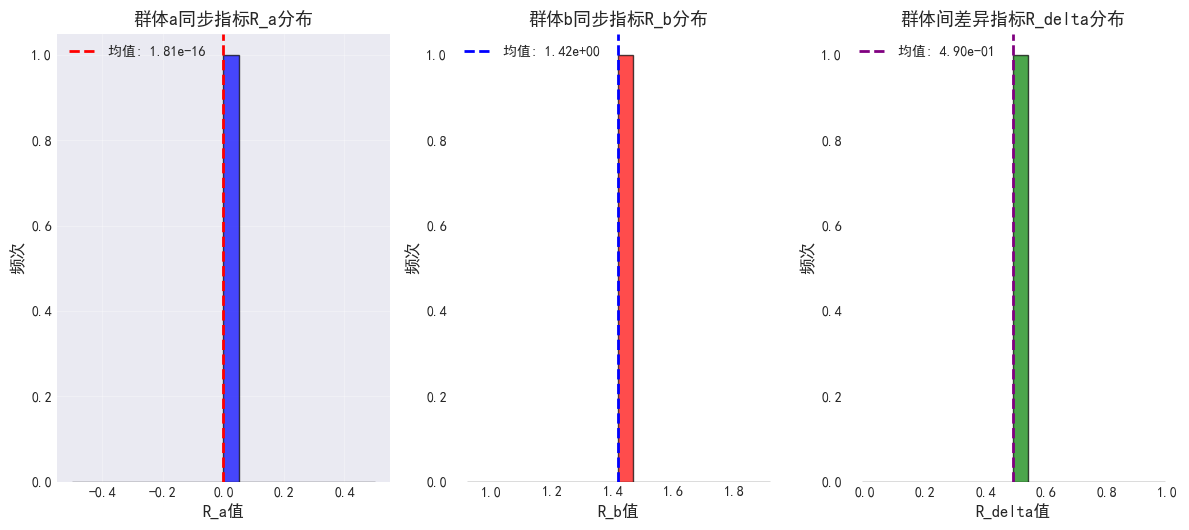

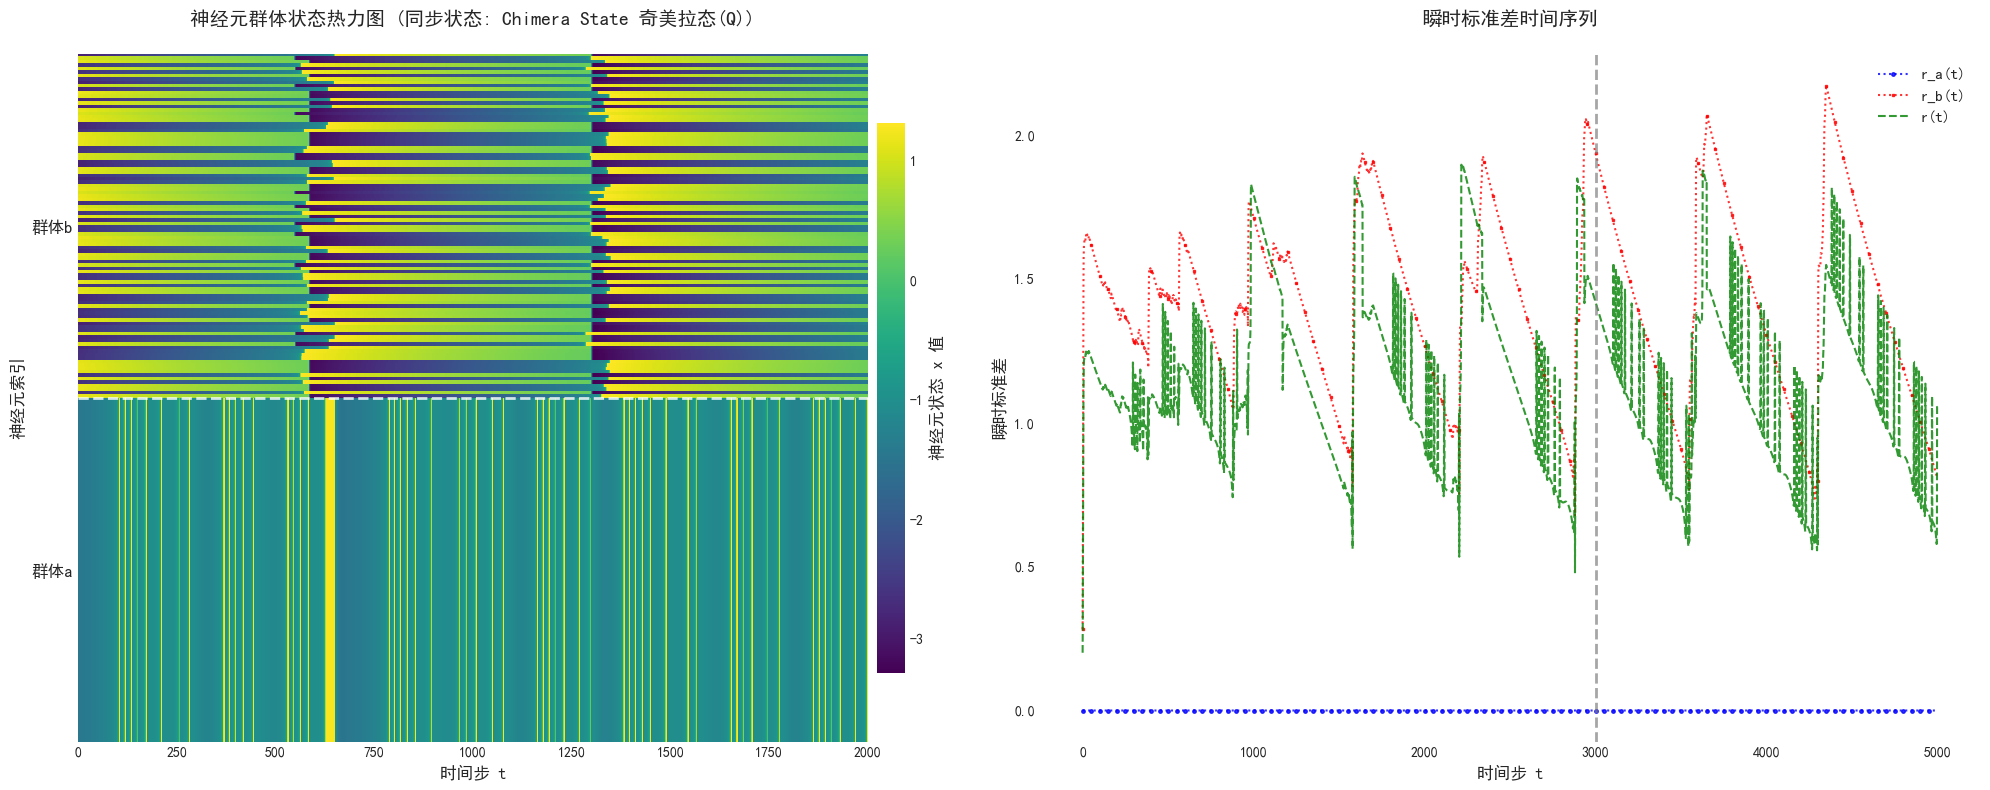


模拟完成！总共运行了 1 次模拟。


In [8]:
# 设置模拟参数
n = 1  # 模拟次数
n_a = 100
n_b = 100
x_data = []
t_list = []
simulation_results = []  # 存储所有模拟结果
statistics_list = []  # 存储统计信息

print(f"开始运行 {n} 次模拟...")

# 运行多次模拟
for i in range(n):
    # 使用不同的随机种子
    seed = i+103  
    
    print(f"运行模拟 {i+1}/{n} (种子: {seed})...", end=" ")
    
    # 生成数据
    data = generate_two_population_neuron_data(
        n_a=n_a, n_b=n_b,
        alpha_a=4.6, alpha_b=4.6,
        sigma_a=0.225, sigma_b=0.225,
        mu=0.001, gamma=0.005, epsilon=0.002,
        T=5000, transients=3000,  
        seed=seed,x0_a=-1, x0_b=None, y0_a=-3.5, y0_b=None
    )
    cols = []
    for idx in range(1, n_a + 1):
        key = f'神经元_a_{idx:03d}'
        cols += [data[key]['x_transient'], data[key]['y_transient']]
    for idx in range(1, n_b + 1):
        key = f'神经元_b_{idx:03d}'
        cols += [data[key]['x_transient'], data[key]['y_transient']]
    
    x_train = np.column_stack(cols)  # shape: (时间步长, 特征数)
    t_train = data['时间序列']['t']
    x_data.append(x_train) 
    t_list.append(t_train)
    simulation_results.append(data)
    
    # 提取统计信息
    stats = {
        'seed': seed,
        'R_a': data['params']['⟨σa⟩ (R_a)'],
        'R_b': data['params']['⟨σb⟩ (R_b)'],
        'R_t': data['params']['⟨σt⟩ (R_t)'],
        'R_delta': data['params']['⟨δ⟩ (R_delta)'],
        'sync_state': data['params']['同步状态'],
        'sync_a': data['params']['a群体同步'],
        'sync_b': data['params']['b群体同步'],
        'sync_t': data['params']['Rt群体同步'],
        'sync_ab': data['params']['群体间同步']
    }
    statistics_list.append(stats)
    
    print(f"完成 - 同步状态: {stats['sync_state']}")
    print(f"R_a:{stats['R_a']:.6f}   R_b:{stats['R_b']:.6f}    R_t:{stats['R_t']:.6f}     R_delta:{stats['R_delta']:.6f}")

# 创建DataFrame用于分析
statistics_df = pd.DataFrame(statistics_list)

# 分析同步状态
analysis_results = analyze_sync_states(statistics_df)

# 绘制柱状图
plot_sync_statistics_histogram(statistics_df)

# 可视化
last_data = simulation_results[-1]
for i in range(n):
    plot_neuron_analysis_combo(simulation_results[i])
    # 单独绘制热力图
    #plot_neuron_state_heatmap(simulation_results[i])

print(f"\n模拟完成！总共运行了 {len(statistics_df)} 次模拟。")

# 选择library

In [9]:
# 候选的观测函数
ide = ps.IdentityLibrary()
fourier = ps.FourierLibrary(n_frequencies=1)
#ode_lib = ps.PolynomialLibrary(degree=2,include_bias=True,interaction_only=True)# 只有交叉项
ode_lib = ps.PolynomialLibrary(degree=2,include_bias=False,include_interaction=False,interaction_only=False)# 只有平方项
#ode_lib = ps.PolynomialLibrary(degree=2,include_bias=False)# 都有
library_functions = [
    #lambda x: 1/(1-x),  
    lambda x_val, y_val, alpha: (
        alpha / (1 - x_val) + y_val if x_val <= 0 
        else (alpha + y_val if 0 < x_val < alpha + y_val 
              else -1)
    )
]
custom_library = ps.CustomLibrary(library_functions=library_functions)

# 选定观测函数
library = ode_lib

# 进行lift
library.fit(x_data)
x_data_lift = library.transform(x_data)
names = library.get_feature_names()

# 检查观测函数变量名
print(len(names))
#print(names)

800


# 进行拟合

In [10]:
# 离散的迭代方程 or 连续的微分方程
#discrete_time=False
discrete_time=True
dt = 1
# 候选拟合器
lasso_optimizer = Lasso(alpha=0.01, max_iter=2000, fit_intercept=False)
sr3_optimizer = ps.SR3(reg_weight_lam=0.2, regularizer="l1") # score为负
stlsq_optimizer = ps.STLSQ(threshold=0.01, alpha=1e-5, normalize_columns=True)
ssr_optimizer = ps.SSR(criteria='model_residual', normalize_columns=True, kappa=5e-3)
ridge_optimizer = Ridge(alpha=1.0,max_iter=2000,fit_intercept=False,tol=1e-3,solver="auto")
elastic_net = ElasticNet(
    alpha=0.01,          # 总正则化强度（alpha = l1_ratio*L1 + (1-l1_ratio)*L2）
    l1_ratio=0.5,        # L1占比：0.5表示L1和L2各占50%；1=纯Lasso，0=纯Ridge
    max_iter=2000,
    fit_intercept=False,
    tol=1e-4
)
optimizer = stlsq_optimizer

# 进行拟合
model = ps.SINDy(feature_library=ide, optimizer=optimizer, discrete_time=discrete_time)
model.fit(x_data_lift, t=dt, feature_names=names)
#model.print()

,optimizer,STLSQ(alpha=1...hreshold=0.01)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,discrete_time,True
,degree,1
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,threshold,0.01
,alpha,1e-05


In [11]:
# 计算score
model.score(x_data_lift, t=dt)

0.9402107971587319

# 多步预测

In [18]:
# 单时间序列
#init_data = x_data_lift[0,:]
# 多时间序列
init_data = x_data_lift[0][0,:]

if discrete_time:
    X_data_predicted = model.simulate(init_data,len(t_list[0]))
else:
    X_data_predicted = model.simulate(init_data,t_list[0]) 

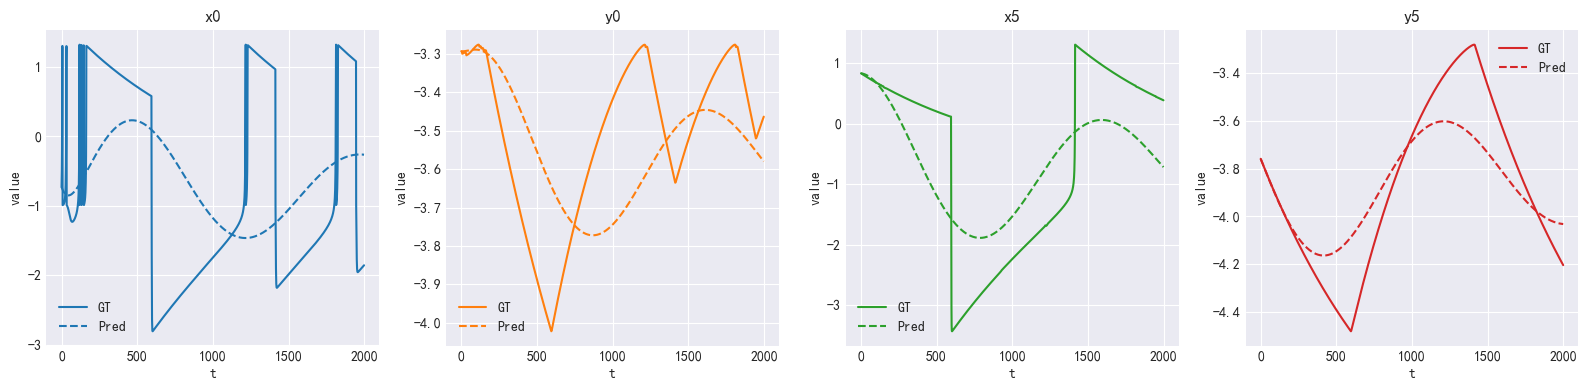

In [19]:
plot_idx = [0, 1, 10, 11]        

channels = ['x0', 'y0', 'x5', 'y5'] 

colors = plt.cm.tab10.colors[:len(plot_idx)]

fig, axes = plt.subplots(1, len(plot_idx),
                         figsize=(4*len(plot_idx), 4),
                         sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ax, idx, name, c in zip(axes, plot_idx, channels, colors):
    # 真实值
    ax.plot(x_data_lift[0][:, idx], ls='-', c=c, label='GT')
    # 预测值
    ax.plot(X_data_predicted[:, idx], ls='--', c=c, label='Pred')

    ax.set_title(name)
    ax.set_xlabel('t')
    ax.set_ylabel('value')
    ax.legend()

plt.tight_layout()
plt.show()

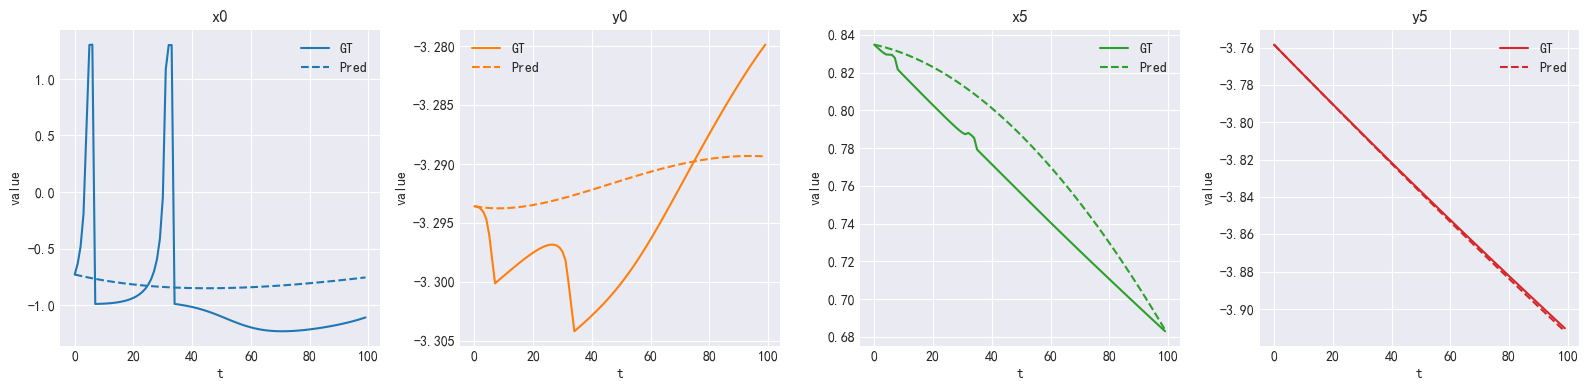

In [20]:
plot_idx = [0, 1, 10, 11]        

channels = ['x0', 'y0', 'x5', 'y5'] 

colors = plt.cm.tab10.colors[:len(plot_idx)]

fig, axes = plt.subplots(1, len(plot_idx),
                         figsize=(4*len(plot_idx), 4),
                         sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ax, idx, name, c in zip(axes, plot_idx, channels, colors):
    # 真实值
    ax.plot(x_data_lift[0][:100, idx], ls='-', c=c, label='GT')
    # 预测值
    ax.plot(X_data_predicted[:100, idx], ls='--', c=c, label='Pred')

    ax.set_title(name)
    ax.set_xlabel('t')
    ax.set_ylabel('value')
    ax.legend()

plt.tight_layout()
plt.show()

# svd分解

(800, 800)


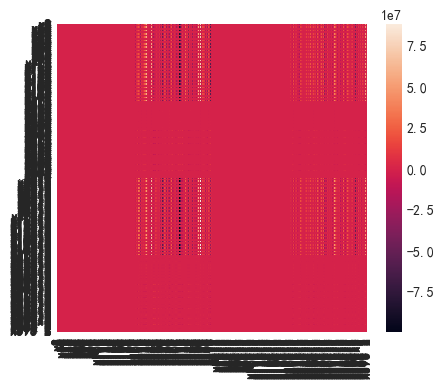

In [12]:
# 提取和处理系数矩阵
A = model.coefficients()
print(A.shape)
if discrete_time==False:
    A = scipy.linalg.expm(A)

# 只设置参数，不自动显示全部
plt.figure(figsize=(5, 4)) # 把画布搞大一点
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(A, xticklabels=names, yticklabels=names)
# 旋转横轴标签，避免重叠
plt.xticks(rotation=90)  # 旋转90度
plt.yticks(rotation=0)   # 纵轴保持水平
plt.show()

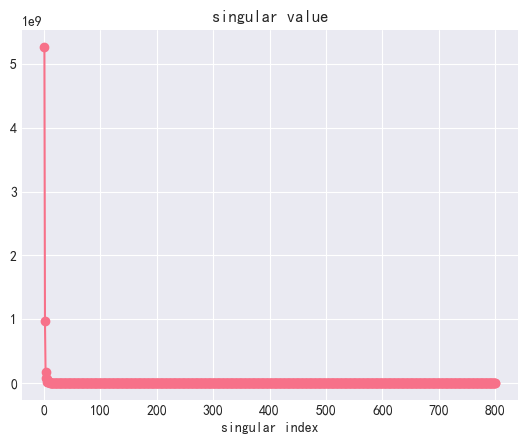

[5.26967406e+09 9.62178260e+08 1.70812037e+08 7.41938030e+07
 5.26728971e+07 1.53328288e+07 1.44750913e+07 1.01110803e+07
 8.50770124e+06 4.73199417e+06 3.90211562e+06 3.16953825e+06
 2.62244077e+06 2.59213946e+06 2.14645801e+06 2.04968734e+06
 1.89946775e+06 1.84450357e+06 1.75283581e+06 1.69052862e+06
 1.51362701e+06 1.40205359e+06 1.27970940e+06 1.18919757e+06
 1.09585050e+06 9.54865822e+05 9.27427005e+05 8.32569472e+05
 7.96572314e+05 7.93817500e+05 7.74307293e+05 7.23277579e+05
 6.79331577e+05 6.62359640e+05 6.47048461e+05 5.92979342e+05
 5.77631551e+05 5.40851045e+05 5.13187737e+05 4.85566731e+05
 4.43745275e+05 3.88066024e+05 3.70186700e+05 3.58295509e+05
 3.42108166e+05 3.29003561e+05 3.09984541e+05 2.91180527e+05
 2.75303314e+05 2.72016385e+05 2.61814596e+05 2.50357481e+05
 2.43532932e+05 2.34557821e+05 2.33895465e+05 2.14580393e+05
 2.07653722e+05 2.01972518e+05 1.97548449e+05 1.89441182e+05
 1.79508362e+05 1.73081879e+05 1.66917294e+05 1.62054459e+05
 1.54633547e+05 1.465660

In [13]:
# SVD
U,S,V = np.linalg.svd(A)
plt.figure()
plt.plot(range(1,len(S)+1), S, marker='o')
# plt.semilogy(range(1, len(S)+1), S, marker='o')   # 对数坐标轴
plt.grid(True)
plt.xlabel('singular index')
plt.title('singular value')
plt.show()
print(S)

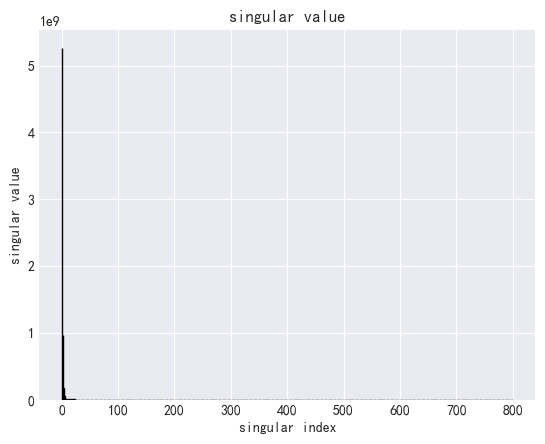

In [14]:
plt.figure()
plt.bar(np.arange(1, len(S)+1), S, color='steelblue', edgecolor='k')
plt.grid(True, axis='y')          # 只留横网格，看起来更干净
plt.xlabel('singular index')
plt.ylabel('singular value')
plt.title('singular value')
plt.show()

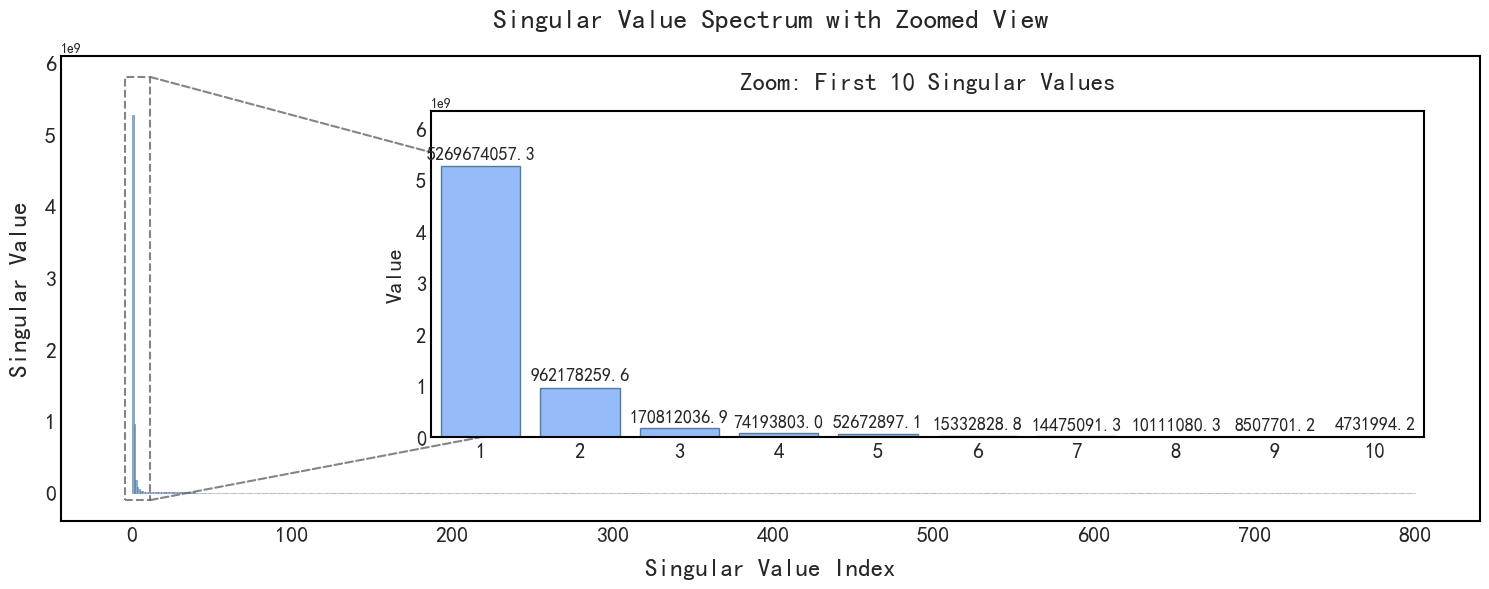

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

# 创建图形，设置图形大小（宽度15英寸，高度6英寸）
plt.figure(figsize=(15, 6))

# 主图 - 绘制全部奇异值的柱状图
# 颜色改为浅蓝色 (#8AB4F8) 用于主图
bars = plt.bar(np.arange(1, len(S)+1), S, 
               color='#6C9BC4', edgecolor='#5C7CA5', alpha=0.8, linewidth=0.5)

# 设置主图坐标轴标签 - 增大字体和加粗
plt.xlabel('Singular Value Index', fontsize=18, fontweight='bold', labelpad=10)  # 标签字体大小18，加粗，与坐标轴距离10点
plt.ylabel('Singular Value', fontsize=18, fontweight='bold', labelpad=10)  # 标签字体大小18，加粗，与坐标轴距离10点
plt.title('Singular Value Spectrum with Zoomed View', fontsize=20, fontweight='bold', pad=20)  # 标题字体大小20，加粗，与图形顶部距离20点

# 移除主图网格线
plt.grid(False)

# 获取当前坐标轴对象
ax_main = plt.gca()

# 设置主图边框样式
for spine in ax_main.spines.values():
    spine.set_color('black')  # 边框颜色为黑色
    spine.set_linewidth(1.5)  # 边框线宽1.5
    spine.set_visible(True)  # 确保所有边框都显示

# 设置主图坐标轴刻度标签样式
ax_main.tick_params(axis='both', which='major', labelsize=16, width=1.5)  # 刻度标签大小16，刻度线宽1.5

# 在右上角创建放大图（内插图）- 占比70%
n = 10  # 设置放大前10个奇异值，修改此值可改变放大数量
# 创建内嵌坐标轴，宽度和高度占主图的70%
# borderpad=4 表示内嵌图与主图边缘的间距为4点
ax_inset = inset_axes(ax_main, 
                      width="70%",   # 内插图宽度占主图的70%，减小此值可缩小放大图
                      height="70%",  # 内插图高度占主图的70%，减小此值可缩小放大图
                      loc='upper right',  # 位于主图右上角
                      borderpad=4)   # 与主图边缘的间距为4点，增大此值可使放大图更靠近中心

# 绘制放大图 - 使用深蓝色 (#6C9BC4) 用于放大图
bars_inset = ax_inset.bar(np.arange(1, n+1), S[:n], 
                          color='#8AB4F8', edgecolor='#4A708B', alpha=0.9, linewidth=1)  # 深蓝色柱状图
ax_inset.set_xlim(0.5, n+0.5)  # 设置x轴范围为0.5到n+0.5，确保柱状图居中显示

# 设置放大图y轴范围
y_max = max(S[:n])  # 获取放大区域的最大值
ax_inset.set_ylim(0, y_max * 1.2)  # 设置y轴范围，上方留20%的空白区域，修改1.2可调整空白比例

# 设置放大图坐标轴标签
# ax_inset.set_xlabel(f'Index (1-{n})', fontsize=16, fontweight='bold', labelpad=8)  # 已被注释的x轴标签
ax_inset.set_ylabel('Value', fontsize=16, fontweight='bold', labelpad=8)  # y轴标签，字体大小16，加粗
ax_inset.set_title(f'Zoom: First {n} Singular Values', fontsize=18, fontweight='bold', pad=15)  # 标题，字体大小18，加粗

# 设置放大图x轴刻度
ax_inset.set_xticks(np.arange(1, n+1))  # 设置x轴刻度位置为1到n
ax_inset.tick_params(axis='both', labelsize=15, width=1.5)  # 刻度标签大小15，刻度线宽1.5

# 移除放大图的网格线
ax_inset.grid(False)

# 设置放大图边框样式
for spine in ax_inset.spines.values():
    spine.set_color('black')  # 边框颜色为黑色
    spine.set_linewidth(1.5)  # 边框线宽1.5

# 设置背景颜色为纯白色
ax_main.set_facecolor('white')  # 主图背景色
ax_inset.set_facecolor('white')  # 放大图背景色

# 在放大图上添加数值标签
for i, (bar, v) in enumerate(zip(bars_inset, S[:n]), 1):
    height = bar.get_height()  # 获取柱状图高度
    # 在柱状图顶部添加数值标签
    ax_inset.text(bar.get_x() + bar.get_width()/2., height + y_max*0.02, 
                  f'{v:.1f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# 在主图上绘制虚线框标记放大区域
rect_padding = 0.2  # 虚线框的边距大小，增大此值可增加虚线框与柱状图的间距
# 设置虚线框的x坐标范围，-3.5到n+1.5确保框住前n个柱状图并有足够边距
rect_x = [-3.5 - rect_padding, n+1.5 + rect_padding]  # x范围，减小-3.5可使框左移，增大n+1.5可使框右移
rect_y = [-y_max*0.02, max(S[:n]) + y_max*0.1]  # y范围，修改-0.02和0.1可调整上下边距

# 创建黑灰色虚线框
rect = Rectangle((rect_x[0], rect_y[0]),  # 矩形左下角坐标
                 rect_x[1] - rect_x[0],  # 矩形宽度
                 rect_y[1] - rect_y[0],  # 矩形高度
                 linewidth=1.5, linestyle='--',  # 线宽1.5，虚线样式
                 edgecolor='#666666',  # 边框颜色为深灰色
                 facecolor='none',  # 无填充色
                 alpha=0.8, zorder=10)  # 透明度0.8，图层层级10（确保在最上层）
ax_main.add_patch(rect)  # 将矩形添加到主图

# 添加第一条连接线：从虚线框右下角到放大图左下角
con1 = ConnectionPatch(
    xyA=(rect_x[1], rect_y[0]),  # 起点：虚线框右下角
    xyB=(1, 0),  # 终点：放大图左下角
    coordsA="data", coordsB="data",  # 使用数据坐标
    axesA=ax_main, axesB=ax_inset,  # 连接主图和放大图
    color="#666666", linestyle="--", linewidth=1.5, alpha=0.8  # 深灰色虚线
)

# 添加第二条连接线：从虚线框右上角到放大图左上角
con2 = ConnectionPatch(
    xyA=(rect_x[1], rect_y[1]),  # 起点：虚线框右上角
    xyB=(1, y_max),  # 终点：放大图左上角
    coordsA="data", coordsB="data",  # 使用数据坐标
    axesA=ax_main, axesB=ax_inset,  # 连接主图和放大图
    color="#666666", linestyle="--", linewidth=1.5, alpha=0.8  # 深灰色虚线
)

# 将连接线添加到主图
ax_main.add_artist(con1)
ax_main.add_artist(con2)

# 调整图形布局，确保所有元素不重叠
plt.tight_layout()

# 显示图形
plt.show()

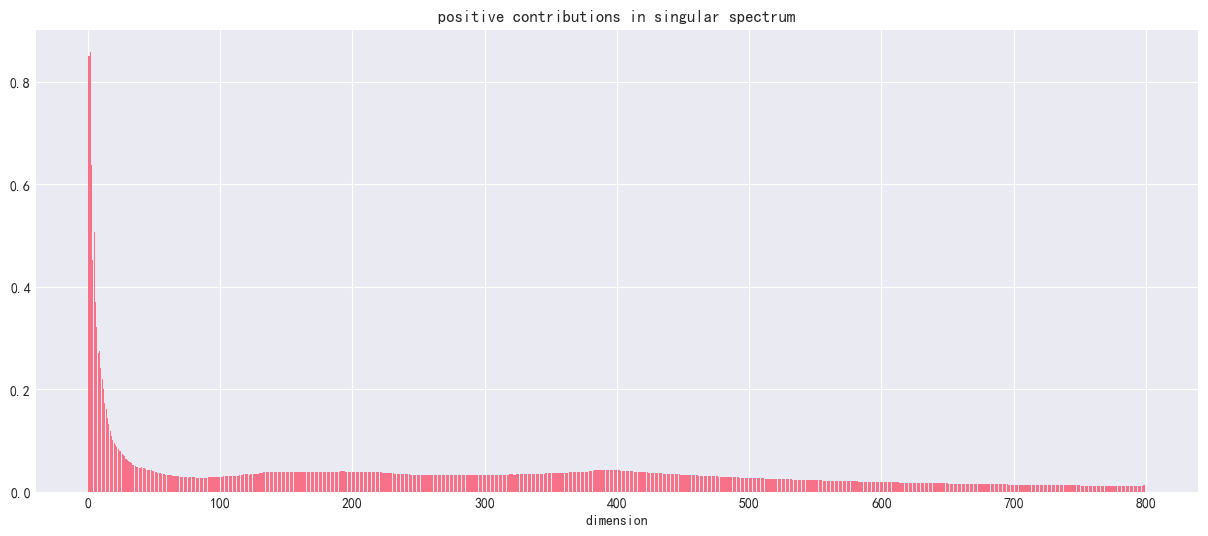

In [16]:
# 多尺度因果力分布
diff = get_positive_contributions(S)
plt.figure(figsize=(15, 6))
plt.bar(range(1,len(diff)+1), diff) 
plt.xlabel('dimension')
plt.title('positive contributions in singular spectrum')
plt.show()

In [17]:
# 计算EC
print(compute_entropy(diff))

9.04130889774271


In [18]:
def get_positive_contributions2(sing_values):  
    ave_sig = []
    for i in range(len(sing_values)):
        ave_sig.append(np.log(np.mean(sing_values[0:i+1])))

    output = []
    for id in range(len(ave_sig)-1):
        diff = ave_sig[id] - ave_sig[id+1]
        output.append(diff)
    return output

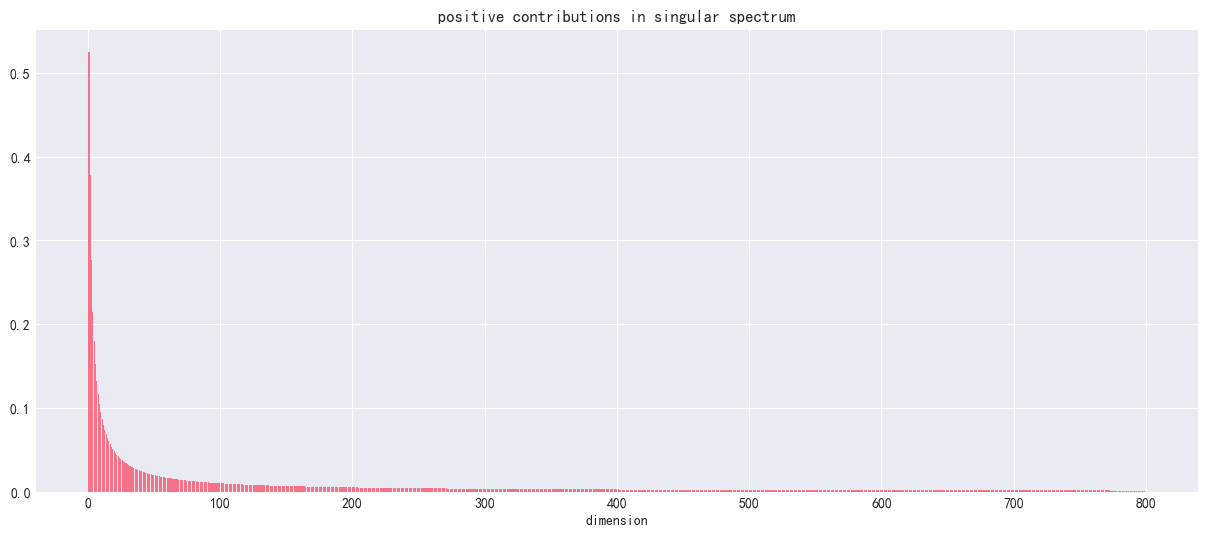

In [19]:
# 多尺度因果力分布
diff2 = get_positive_contributions2(S)
plt.figure(figsize=(15, 6))
plt.bar(range(1,len(diff2)+1), diff2) 
plt.xlabel('dimension')
plt.title('positive contributions in singular spectrum')
plt.show()

In [20]:
# 计算EC
print(compute_entropy(diff2))

7.700574442143391


In [21]:
import pickle
with open("diffQ100.pkl", "wb") as f:
    pickle.dump(diff, f)

In [22]:
import pickle
with open("diff2Q100.pkl", "wb") as f:
    pickle.dump(diff2, f)

In [24]:
# 选取截断
rank = 8
S_macro = S[:rank]
delt_gamma = sum(S_macro) / rank - sum(S) / len(S)
print(delt_gamma)

0.33254587454984563


# 输出粗粒化表达式

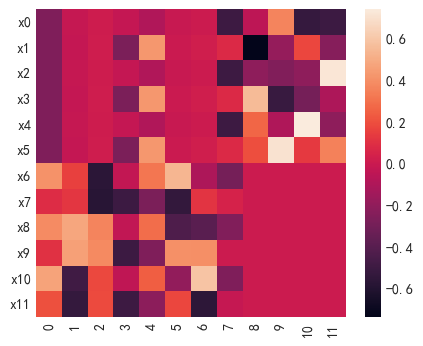

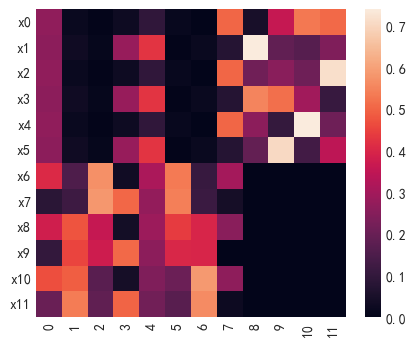

In [27]:
# 绘制奇异向量
U_abs = np.abs(U)

plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U, yticklabels=names)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U_abs, yticklabels=names)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show() 

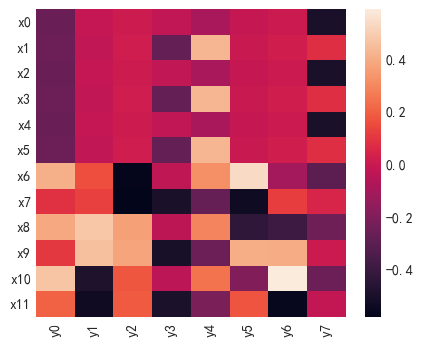

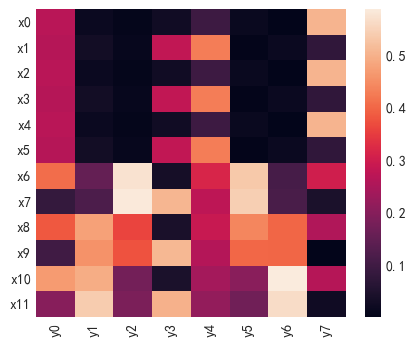

In [28]:
# 粗粒化函数系数
macro_name = [f'y{i}' for i in range(rank)]
coarse_grain_coff = U[:,:rank]

plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(coarse_grain_coff, yticklabels=names, xticklabels=macro_name)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(5, 4)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(np.abs(coarse_grain_coff), yticklabels=names, xticklabels=macro_name)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()

In [29]:
# 输出粗粒化函数表达式
print_equations(coarse_grain_coff, names, macro_name)

y0 = -0.2659 * x0 - 0.2611 * x1 - 0.2659 * x2 - 0.2611 * x3 - 0.2659 * x4 - 0.2611 * x5 + 0.4054 * x6 + 0.0809 * x7 + 0.3811 * x8 + 0.0995 * x9 + 0.4663 * x10 + 0.1997 * x11
------------------------------
y1 = -0.0182 * x0 - 0.0294 * x1 - 0.0182 * x2 - 0.0294 * x3 - 0.0182 * x4 - 0.0294 * x5 + 0.1528 * x6 + 0.1188 * x7 + 0.4758 * x8 + 0.4533 * x9 - 0.4902 * x10 - 0.5356 * x11
------------------------------
y2 = 0.0052 * x0 + 0.0110 * x1 + 0.0052 * x2 + 0.0110 * x3 + 0.0052 * x4 + 0.0110 * x5 - 0.5709 * x6 - 0.5833 * x7 + 0.3589 * x8 + 0.3754 * x9 + 0.1727 * x10 + 0.1839 * x11
------------------------------
y3 = -0.0270 * x0 - 0.2776 * x1 - 0.0270 * x2 - 0.2776 * x3 - 0.0270 * x4 - 0.2776 * x5 - 0.0325 * x6 - 0.5055 * x7 - 0.0393 * x8 - 0.5079 * x9 - 0.0426 * x10 - 0.4987 * x11
------------------------------
y4 = -0.0953 * x0 + 0.4258 * x1 - 0.0953 * x2 + 0.4258 * x3 - 0.0953 * x4 + 0.4258 * x5 + 0.3146 * x6 - 0.2743 * x7 + 0.2878 * x8 - 0.2609 * x9 + 0.2391 * x10 - 0.2156 * x11
-------

# 描述宏观演化

In [30]:
macro_data = x_data_lift[0] @ coarse_grain_coff
macro_dim = macro_data.shape[1]

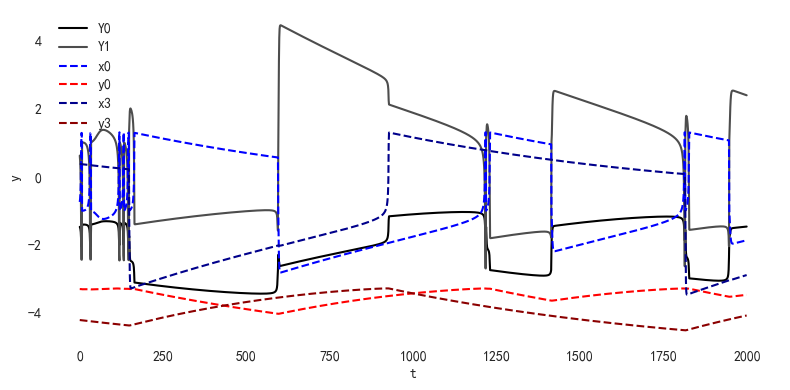

In [42]:
# 原始数据
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(macro_data[:,4], color='0', label='Y0')  
ax.plot(macro_data[:,7], color='0.3', label='Y1')
#ax.plot(macro_data[:,2], color='0.5', label='Y2')  
#ax.plot(macro_data[:,3], color='0.8', label='Y3')
ax.plot(x_data[0][:,0], '--',color='blue', label='x0')
ax.plot(x_data[0][:,1], '--',color='red', label='y0')
ax.plot(x_data[0][:,6], '--',color='darkblue', label='x3')
ax.plot(x_data[0][:,7], '--',color='darkred', label='y3')
ax.legend()
ax.set(xlabel='t', ylabel='y')
ax.set_facecolor('white')  
ax.grid(False)
fig.tight_layout()
plt.show()

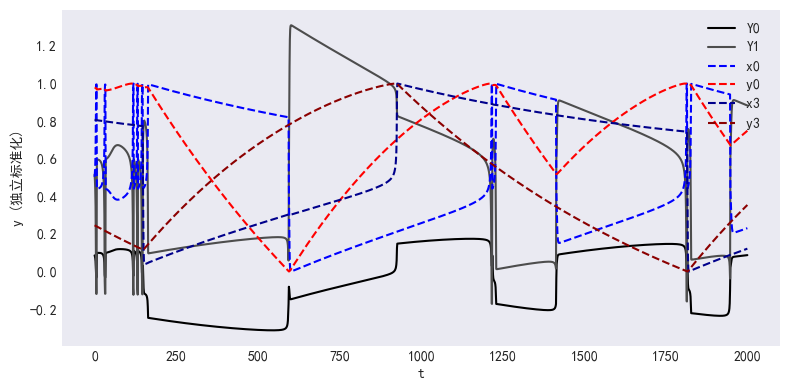

In [43]:
# 各自标准化到0-1
fig, ax = plt.subplots(figsize=(8, 4))

# 独立标准化每条曲线
ax.plot((macro_data[:,4] - macro_data[:,0].min()) / (macro_data[:,0].max() - macro_data[:,0].min()), 
        color='0', label='Y0')
ax.plot((macro_data[:,7] - macro_data[:,1].min()) / (macro_data[:,1].max() - macro_data[:,1].min()), 
        color='0.3', label='Y1')
#ax.plot((macro_data[:,2] - macro_data[:,2].min()) / (macro_data[:,2].max() - macro_data[:,2].min()), 
#        color='0.5', label='Y2')
#ax.plot((macro_data[:,3] - macro_data[:,3].min()) / (macro_data[:,3].max() - macro_data[:,3].min()), 
#        color='0.8', label='Y3')

# 标准化x_data的每条曲线
#, (20, 'darkblue', 'x10'), (21, 'darkred', 'y10')
for i, (idx, color, name) in enumerate([(0, 'blue', 'x0'), (1, 'red', 'y0'), (6, 'darkblue', 'x3'), (7, 'darkred', 'y3')]):
    data = x_data[0][:, idx]
    data_min, data_max = data.min(), data.max()
    if data_max == data_min:
        normalized_data = np.ones_like(data) * 0.5
    else:
        normalized_data = (data - data_min) / (data_max - data_min)
    ax.plot(normalized_data, '--', color=color, label=f'{name} ')

ax.legend()
ax.set(xlabel='t', ylabel='y (独立标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

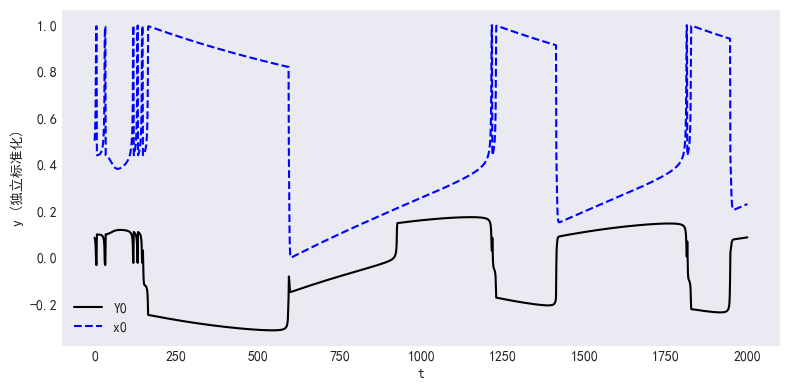

In [45]:
# 各自标准化到0-1
fig, ax = plt.subplots(figsize=(8, 4))

# 独立标准化每条曲线
ax.plot((macro_data[:,4] - macro_data[:,0].min()) / (macro_data[:,0].max() - macro_data[:,0].min()), 
        color='0', label='Y0')

# 标准化x_data的每条曲线
#, (20, 'darkblue', 'x10'), (21, 'darkred', 'y10')
for i, (idx, color, name) in enumerate([(0, 'blue', 'x0')]):
    data = x_data[0][:, idx]
    data_min, data_max = data.min(), data.max()
    if data_max == data_min:
        normalized_data = np.ones_like(data) * 0.5
    else:
        normalized_data = (data - data_min) / (data_max - data_min)
    ax.plot(normalized_data, '--', color=color, label=f'{name} ')

ax.legend()
ax.set(xlabel='t', ylabel='y (独立标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

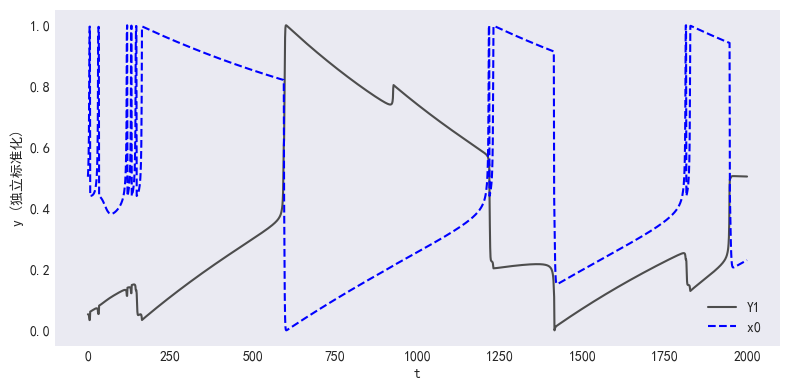

In [35]:
# 各自标准化到0-1
fig, ax = plt.subplots(figsize=(8, 4))

# 独立标准化每条曲线
ax.plot((macro_data[:,1] - macro_data[:,1].min()) / (macro_data[:,1].max() - macro_data[:,1].min()), 
        color='0.3', label='Y1')
for i, (idx, color, name) in enumerate([(0, 'blue', 'x0')]):
    data = x_data[0][:, idx]
    data_min, data_max = data.min(), data.max()
    if data_max == data_min:
        normalized_data = np.ones_like(data) * 0.5
    else:
        normalized_data = (data - data_min) / (data_max - data_min)
    ax.plot(normalized_data, '--', color=color, label=f'{name} ')

ax.legend()
ax.set(xlabel='t', ylabel='y (独立标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

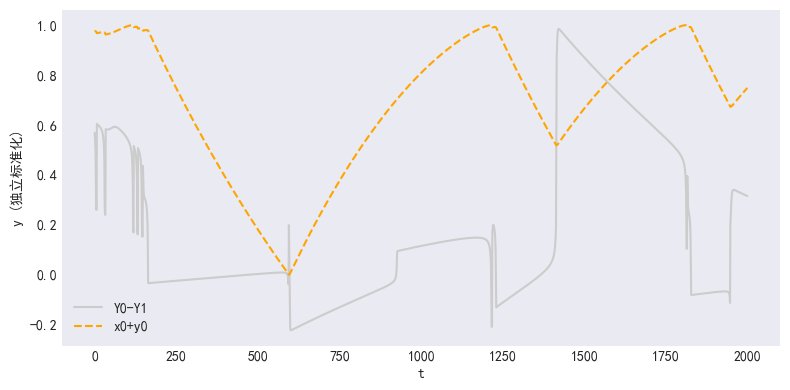

In [36]:
# 标准化后+-
fig, ax = plt.subplots(figsize=(8, 4))
Y0=(macro_data[:,0] - macro_data[:,0].min()) / (macro_data[:,0].max() - macro_data[:,0].min())
Y1=(macro_data[:,1] - macro_data[:,1].min()) / (macro_data[:,1].max() - macro_data[:,1].min())
x0=(x_data[0][:,0] - x_data[0][:,0].min()) / (x_data[0][:,0].max() - x_data[0][:,0].min())
y0=(x_data[0][:,1] - x_data[0][:,1].min()) / (x_data[0][:,1].max() - x_data[0][:,1].min())
#ax.plot(Y0+Y1,color='0.3', label='Y0+Y1')
ax.plot(Y0-Y1,color='0.8', label='Y0-Y1')
ax.plot(y0, '--', color='orange', label='x0+y0')
#ax.plot(x0-y0, '--', color='red', label='x0-y0')
ax.legend()
ax.set(xlabel='t', ylabel='y (独立标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

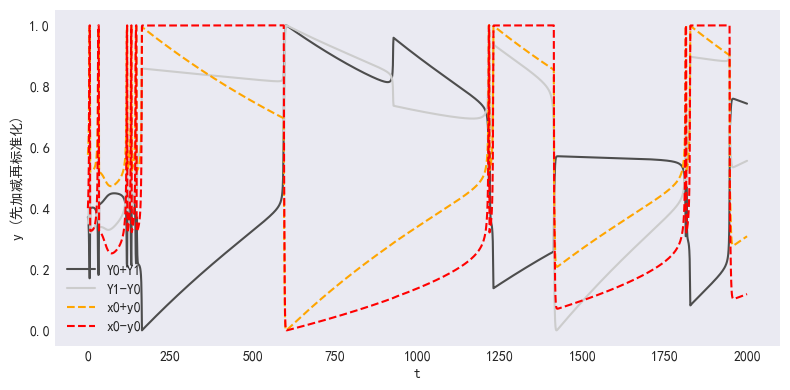

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

sum_raw_01 = macro_data[:, 0] + macro_data[:, 1]   # Y0+Y1
dif_raw_01 = macro_data[:, 1] - macro_data[:, 0]   # Y1-Y0

sum_raw_xy = x_data[0][:, 0] + x_data[0][:, 1]     # x0+y0
dif_raw_xy = x_data[0][:, 0] - x_data[0][:, 1]     # x0-y0

def minmax(a):
    return (a - a.min()) / (a.max() - a.min())

Y0_plus_Y1 = minmax(sum_raw_01)
Y1_minus_Y0 = minmax(dif_raw_01)
x0_plus_y0 = minmax(sum_raw_xy)
x0_minus_y0 = minmax(dif_raw_xy)

ax.plot(Y0_plus_Y1, color='0.3', label='Y0+Y1')
ax.plot(Y1_minus_Y0, color='0.8', label='Y1-Y0')
ax.plot(x0_plus_y0, '--', color='orange', label='x0+y0')
ax.plot(x0_minus_y0, '--', color='red', label='x0-y0')

ax.legend()
ax.set(xlabel='t', ylabel='y (先加减再标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

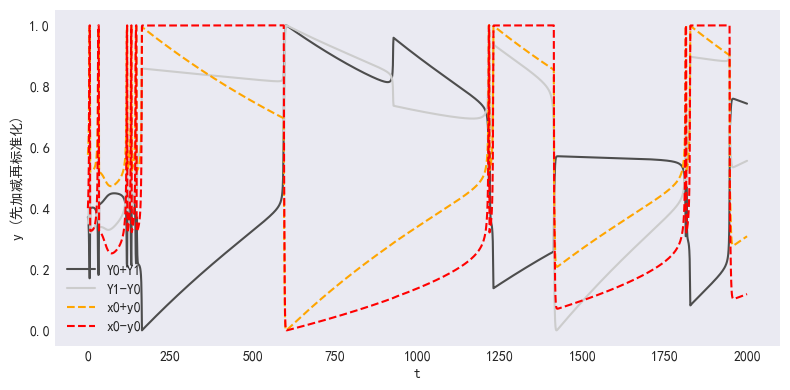

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))

sum_raw_01 = macro_data[:, 0] + macro_data[:, 1]   # Y0+Y1
dif_raw_01 = macro_data[:, 1] - macro_data[:, 0]   # Y1-Y0

sum_raw_xy = x_data[0][:, 0] + x_data[0][:, 1]     # x0+y0
dif_raw_xy = x_data[0][:, 0] - x_data[0][:, 1]     # x0-y0

def minmax(a):
    return (a - a.min()) / (a.max() - a.min())

Y0_plus_Y1 = minmax(sum_raw_01)
Y1_minus_Y0 = minmax(dif_raw_01)
x0_plus_y0 = minmax(sum_raw_xy)
x0_minus_y0 = minmax(dif_raw_xy)

ax.plot(Y0_plus_Y1, color='0.3', label='Y0+Y1')
ax.plot(Y1_minus_Y0, color='0.8', label='Y1-Y0')
ax.plot(x0_plus_y0, '--', color='orange', label='x0+y0')
ax.plot(x0_minus_y0, '--', color='red', label='x0-y0')

ax.legend()
ax.set(xlabel='t', ylabel='y (先加减再标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

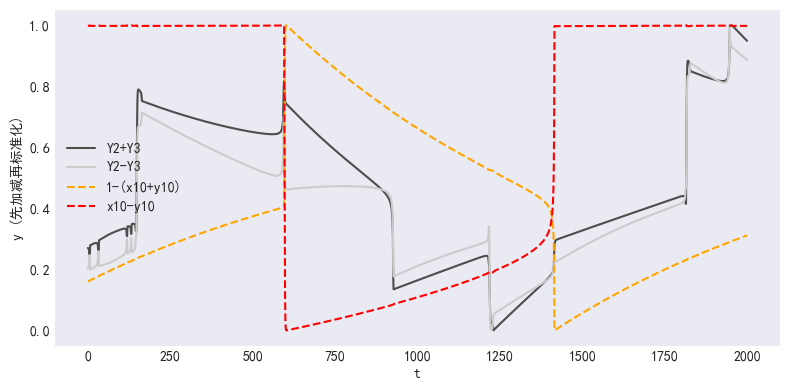

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))

sum_raw_01 = macro_data[:, 2] + macro_data[:, 3]   # Y0+Y1
dif_raw_01 = macro_data[:, 2] - macro_data[:, 3]   # Y1-Y0

sum_raw_xy = x_data[0][:, 10] + x_data[0][:, 11]     # x0+y0
dif_raw_xy = x_data[0][:, 10] - x_data[0][:, 11]     # x0-y0

def minmax(a):
    return (a - a.min()) / (a.max() - a.min())

Y0_plus_Y1 = minmax(sum_raw_01)
Y1_minus_Y0 = minmax(dif_raw_01)
x0_plus_y0 = minmax(sum_raw_xy)
x0_minus_y0 = minmax(dif_raw_xy)

ax.plot(Y0_plus_Y1, color='0.3', label='Y2+Y3')
ax.plot(Y1_minus_Y0, color='0.8', label='Y2-Y3')
ax.plot(1-x0_plus_y0, '--', color='orange', label='1-(x10+y10)')
ax.plot(x0_minus_y0, '--', color='red', label='x10-y10')

ax.legend()
ax.set(xlabel='t', ylabel='y (先加减再标准化)')
ax.grid(False)
fig.tight_layout()
plt.show()

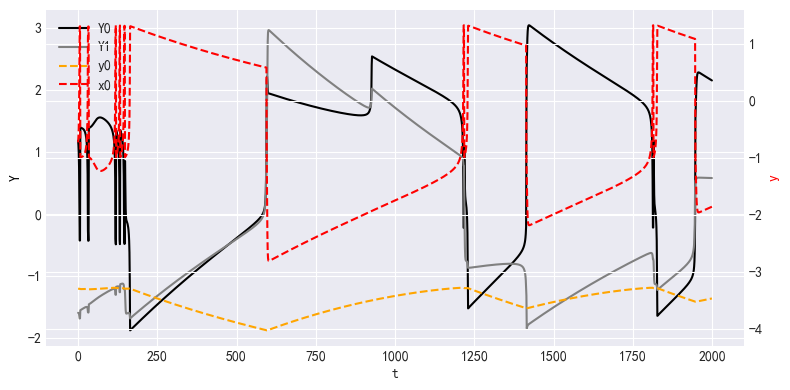

In [40]:
# 两轴
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(macro_data[:,0],color='k', label='Y0')
ax1.plot(macro_data[:,1],color='grey', label='Y1')
ax1.set_ylabel('Y', color='k')
ax1.set_xlabel('t')

ax2 = ax1.twinx()
ax2.plot(x_data[0][:,1], '--', color='orange', label='y0')
ax2.plot(x_data[0][:,0], '--', color='red', label='x0')
ax2.set_ylabel('y', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.tight_layout()
plt.show()

In [41]:
# 给出宏观动力学方程
A_macro = coarse_grain_coff.T @ A @ coarse_grain_coff
macro_name_k = [i+'[k]' for i in macro_name]
macro_name_next = [i+'[k+1]' for i in macro_name]
print_equations(A_macro, macro_name_k, macro_name_next)

y0[k+1] = 1.0111 * y0[k] - 0.0000 * y1[k] + 0.0002 * y2[k] + 0.0010 * y3[k] + 0.0055 * y4[k] - 0.0002 * y5[k] + 0.0012 * y6[k] + 0.0145 * y7[k]
------------------------------
y1[k+1] = 0.0000 * y0[k] + 1.0072 * y1[k] + 0.0000 * y2[k] + 0.0001 * y3[k] + 0.0008 * y4[k] - 0.0004 * y5[k] - 0.0083 * y6[k] + 0.0008 * y7[k]
------------------------------
y2[k+1] = -0.0002 * y0[k] - 0.0000 * y1[k] + 1.0068 * y2[k] - 0.0001 * y3[k] - 0.0005 * y4[k] - 0.0080 * y5[k] + 0.0003 * y6[k] + 0.0003 * y7[k]
------------------------------
y3[k+1] = -0.0011 * y0[k] - 0.0001 * y1[k] + 0.0001 * y2[k] + 1.0003 * y3[k] - 0.0010 * y4[k] + 0.0001 * y5[k] - 0.0001 * y6[k] + 0.0021 * y7[k]
------------------------------
y4[k+1] = -0.0057 * y0[k] - 0.0008 * y1[k] + 0.0005 * y2[k] + 0.0009 * y3[k] + 0.9965 * y4[k] + 0.0002 * y5[k] - 0.0002 * y6[k] + 0.0048 * y7[k]
------------------------------
y5[k+1] = 0.0002 * y0[k] + 0.0004 * y1[k] + 0.0081 * y2[k] - 0.0001 * y3[k] - 0.0002 * y4[k] + 0.9927 * y5[k] - 0.0000 * y